In [40]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# Paths
DATA_DIR = Path("../dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

# Load data
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head(2)


Train shape: (75000, 4)
Test shape: (75000, 3)


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12


In [41]:
import re
import numpy as np
import pandas as pd

def extract_units(text):
    if not isinstance(text, str):
        return None
    t = text.lower()

    patterns = [
        (r'(\d+(\.\d+)?)\s*(kg|kilogram|kilograms)', 1000.0, 'g'),
        (r'(\d+(\.\d+)?)\s*(g|gram|grams)', 1.0, 'g'),
        (r'(\d+(\.\d+)?)\s*(lb|pound|pounds)', 453.592, 'g'),
        (r'(\d+(\.\d+)?)\s*(oz|ounce|ounces)', 28.3495, 'g'),

        (r'(\d+(\.\d+)?)\s*(l|liter|liters|litre|litres)', 1000.0, 'ml'),
        (r'(\d+(\.\d+)?)\s*(ml|milliliter|milliliters|millilitre|millilitres)', 1.0, 'ml'),

        (r'(\d+(\.\d+)?)\s*(count|ct|pcs|pieces|capsules|tabs|tablets|bags|pods|bars|sticks)', 1.0, 'count'),
    ]

    qty_g = []; qty_ml = []; qty_count = []

    for pat, factor, typ in patterns:
        for m in re.finditer(pat, t):
            val = float(m.group(1)) * factor
            if typ == 'g': qty_g.append(val)
            elif typ == 'ml': qty_ml.append(val)
            elif typ == 'count': qty_count.append(val)

    # pack-of expressions
    pack = 1.0
    m = re.search(r'(pack of|pack)\s*(\d+)', t)
    if m: pack = float(m.group(2))
    m2 = re.search(r'(\d+)\s*-\s*pack', t)
    if m2: pack = float(m2.group(1))

    return {
        'qty_g_total': sum(qty_g) if qty_g else np.nan,
        'qty_ml_total': sum(qty_ml) if qty_ml else np.nan,
        'qty_count_total': sum(qty_count) if qty_count else np.nan,
        'pack_est': pack
    }

def build_quantity_features(df):
    out = df['catalog_content'].apply(extract_units)
    d = pd.json_normalize(out)
    for col in ['qty_g_total','qty_ml_total','qty_count_total','pack_est']:
        if col not in d: d[col] = np.nan

    d['g_per_pack']    = d['qty_g_total']    / d['pack_est']
    d['ml_per_pack']   = d['qty_ml_total']   / d['pack_est']
    d['count_per_pack']= d['qty_count_total']/ d['pack_est']

    for c in ['qty_g_total','qty_ml_total','qty_count_total',
              'g_per_pack','ml_per_pack','count_per_pack']:
        d[f'log1p_{c}'] = np.log1p(d[c])
        d[f'{c}_missing'] = d[c].isna().astype(int)

    d['pack_large_flag'] = (d['pack_est'] >= 6).astype(int)
    return d

q_train = build_quantity_features(train)
q_test  = build_quantity_features(test)

for df, q in [(train, q_train), (test, q_test)]:
    for col in q.columns:
        df[col] = q[col]


In [42]:
CATEGORY_MAP = {
    "coffee": ["coffee", "espresso", "cappuccino"],
    "tea": ["tea", "oolong", "matcha", "earl grey", "chai"],
    "spices": ["spice", "masala", "cumin", "turmeric", "paprika", "oregano", "thyme", "garlic"],
    "sauce": ["sauce", "ketchup", "mayo", "mustard", "salsa", "barbecue", "marinara"],
    "snacks": ["chips", "cookies", "cracker", "snack", "popcorn", "pretzel", "nuts", "trail mix"],
    "cereal": ["cereal", "oats", "granola"],
    "soup": ["soup", "broth", "stock"],
    "pasta": ["pasta", "noodle", "penne", "spaghetti", "macaroni"],
    "baking": ["flour", "sugar", "yeast", "baking", "cocoa"],
    "condiments": ["vinegar", "oil", "olive oil", "soy sauce"],
    "pet": ["dog", "cat", "pet", "kibble", "treats"],
    "beverage": ["juice", "soda", "sparkling", "water", "energy drink"],
}

def tag_categories(text):
    text = str(text).lower()
    tags = {}
    for cat, kws in CATEGORY_MAP.items():
        tags[f"cat_{cat}"] = int(any(kw in text for kw in kws))
    return tags

def build_category_features(df):
    tags = df['catalog_content'].apply(tag_categories)
    return pd.DataFrame(list(tags))

cat_train = build_category_features(train)
cat_test  = build_category_features(test)

train = pd.concat([train, cat_train], axis=1)
test  = pd.concat([test,  cat_test], axis=1)


In [43]:
import re
import numpy as np
import pandas as pd

# --- helpers ---
_NUM = r'(\d+(?:\.\d+)?)'

# normalize unit token -> grams or milliliters
UNIT_MAP = {
    'g':'g','gram':'g','grams':'g',
    'kg':'kg','kilogram':'kg','kilograms':'kg',
    'ml':'ml','milliliter':'ml','milliliters':'ml','millilitre':'ml',
    'l':'l','liter':'l','litre':'l','liters':'l','litres':'l',
    'oz':'oz','ounce':'oz','ounces':'oz',
    'lb':'lb','pound':'lb','pounds':'lb'
}
TO_GRAM = {'g':1.0,'kg':1000.0,'oz':28.3495,'lb':453.592}
TO_ML   = {'ml':1.0,'l':1000.0}

def _safe(s):
    return s if isinstance(s,str) else ""

def extract_pack(text):
    """
    Capture many forms:
      'Pack of 6', '6-pack', '6 pk', '6 ct', '3 x 4', '2×6', '4*3', '12 count', '12 pcs'
    Return an integer >=1
    """
    t = _safe(text).lower()

    # 'pack of N'
    m = re.search(r'pack of\s+(\d+)', t)
    if m: return int(m.group(1))

    # 'N-pack' / 'N pk' / 'N ct' / 'N count' / 'N pcs'
    m = re.search(r'(\d+)\s*(?:-?\s*pack|pk|ct|count|pcs)\b', t)
    if m: return int(m.group(1))

    # cartesian like '3 x 4' or '3×4' or '3*4'
    m = re.search(r'(\d+)\s*[x×*]\s*(\d+)', t)
    if m: return int(m.group(1)) * int(m.group(2))

    # fallback: if 'pack' exists but no number, treat as 1
    if 'pack' in t: return 1
    return 1

def extract_unit_items(text):
    """
    Capture per-item sizes like:
      '500 ml', '1.5 l', '12 oz', '200g', '2 lb', '11.25 oz'
    Also capture multi-sizes in the same string; return list of tuples [(value, unit), ...]
    """
    t = _safe(text).lower()
    t = t.replace('ounces','oz')  # minor normalization

    # match number + unit with optional space
    pairs = re.findall(_NUM+r'\s*(g|kg|ml|l|oz|lb)\b', t)
    # re.findall returns only unit when using two groups; re-run to fetch numbers properly:
    pairs_full = re.findall(rf'{_NUM}\s*(g|kg|ml|l|oz|lb)\b', t)
    out = []
    for v,u in pairs_full:
        try:
            out.append( (float(v), UNIT_MAP.get(u,u)) )
        except:
            pass
    return out

def normalize_to_base(units):
    """
    Convert collected units to ONE scalar:
      - Prefer mass (grams) if any mass is present, else volume (ml)
      - Sum multiple mentions
      - Return np.nan if nothing valid
    """
    if not units: return np.nan
    grams = 0.0
    mls   = 0.0
    has_mass, has_vol = False, False
    for v,u in units:
        if u in TO_GRAM:
            grams += v * TO_GRAM[u]; has_mass=True
        elif u in TO_ML:
            mls   += v * TO_ML[u];   has_vol=True
    if has_mass: return grams
    if has_vol:  return mls
    return np.nan


In [44]:
def build_quantity_features(df):
    # per-item pack count
    df['pack_size'] = df['catalog_content'].apply(extract_pack).astype(float)

    # raw units list + per-item size in base units
    df['unit_list'] = df['catalog_content'].apply(extract_unit_items)
    df['unit_per_item'] = df['unit_list'].apply(normalize_to_base)

    # total content = pack_size * per-item (if both present)
    df['total_content'] = df['pack_size'] * df['unit_per_item']

    # flags
    df['has_unit']   = df['unit_per_item'].notna().astype(int)
    df['has_total']  = df['total_content'].notna().astype(int)
    df['is_bulk']    = (df['pack_size']>=6).astype(int)

    # caps + logs to stabilise
    for col,cap in [('pack_size', 64),
                    ('unit_per_item', 50000),    # 50 kg / 50 L upper safety
                    ('total_content', 500000)]:  # 500 kg / 500 L
        df[col] = df[col].clip(upper=cap)

    for col in ['unit_per_item','total_content']:
        df[f'log_{col}'] = np.log1p(df[col].fillna(0.0))

    return df

train = build_quantity_features(train)
test  = build_quantity_features(test)

# keep text stats you already had
train['text_length'] = train['catalog_content'].astype(str).apply(len)
test['text_length']  = test['catalog_content'].astype(str).apply(len)
train['word_count']  = train['catalog_content'].astype(str).apply(lambda s: len(s.split()))
test['word_count']   = test['catalog_content'].astype(str).apply(lambda s: len(s.split()))


In [45]:
# --- FIX missing brand in test and re-run target encoding ---
def guess_brand(text):
    if not isinstance(text, str) or not text.strip():
        return "unknown"

    m = re.search(r'item name:\s*([^,]+)', text, flags=re.I)
    if m:
        head = m.group(1).strip()
        parts = head.split()
        if len(parts) > 0:
            return parts[0][:30]
        else:
            return "unknown"

    parts = text.split()
    return parts[0][:30] if len(parts) > 0 else "unknown"

# Ensure brand column exists in both train & test
if 'brand' not in train.columns:
    train['brand'] = train['catalog_content'].apply(guess_brand)
if 'brand' not in test.columns:
    test['brand'] = test['catalog_content'].apply(guess_brand)

# Redo target encoding
train['brand_te'], test['brand_te'], _ = kfold_target_encode(train, test, col='brand', target='price')

print("brand_te created ✅")
print("Sample train:\n", train[['brand','brand_te']].head())
print("Sample test:\n", test[['brand','brand_te']].head())


brand_te created ✅
Sample train:
      brand   brand_te
0       La  17.692665
1  Salerno  23.492727
2     Bear  21.713831
3  Judee’s  23.797126
4    kedem  23.647654
Sample test:
        brand   brand_te
0       Rani  24.693125
1    Natural  29.060208
2      Honey  23.959343
3     Vlasic  19.224101
4  McCormick  16.612618


In [48]:
# Pack size
train['pack_size'] = train['catalog_content'].apply(extract_pack_size)
test['pack_size'] = test['catalog_content'].apply(extract_pack_size)

# Raw units (dict with qty_g_total, qty_ml_total, etc.)
train['unit_raw'] = train['catalog_content'].apply(extract_units)
test['unit_raw'] = test['catalog_content'].apply(extract_units)

# ✅ No need to compute normalized_quantity with normalize_units anymore
# Instead, use the engineered columns created in Cell 2:
# qty_g_total, qty_ml_total, qty_count_total, g_per_pack, ml_per_pack, count_per_pack, etc.

# Brand - we will use brand from earlier cells (brand + brand_te)
# train['brand'] = train['catalog_content'].apply(extract_brand)
# test['brand'] = test['catalog_content'].apply(extract_brand)

# Text stats
train['text_length'] = train['catalog_content'].astype(str).apply(len)
test['text_length'] = test['catalog_content'].astype(str).apply(len)

train['word_count'] = train['catalog_content'].astype(str).apply(lambda x: len(x.split()))
test['word_count'] = test['catalog_content'].astype(str).apply(lambda x: len(x.split()))

# Quick peek
cols_to_show = [
    'catalog_content','pack_size','qty_g_total','qty_ml_total',
    'qty_count_total','g_per_pack','ml_per_pack','count_per_pack',
    'brand','text_length','word_count'
]
train[cols_to_show].head(10)


,catalog_content,pack_size,qty_g_total,qty_ml_total,qty_count_total,g_per_pack,ml_per_pack,count_per_pack,brand,text_length,word_count
0,"Item Name: La Victoria Green Taco Sauce Mild, ...",6,340.194000,NaN,NaN,56.699000,NaN,NaN,La,91,18
1,"Item Name: Salerno Cookies, The Original Butte...",4,226.796000,NaN,NaN,56.699000,NaN,NaN,Salerno,511,80
2,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",6,53.864050,NaN,NaN,8.977342,NaN,NaN,Bear,328,59
3,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,1,318.931875,NaN,NaN,318.931875,NaN,NaN,Judee’s,1318,211
4,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",1,720.077300,NaN,NaN,720.077300,NaN,NaN,kedem,155,28
5,"Item Name: Member's Mark Member's Mark, Basil,...",1,177.184375,NaN,NaN,177.184375,NaN,NaN,Member's,222,38
6,Item Name: Goya Foods Sazonador Total Seasonin...,6,1700.970000,NaN,NaN,283.495000,NaN,NaN,Goya,1332,229
7,Item Name: VineCo Original Series Chilean Sauv...,1,NaN,31000.0,NaN,NaN,31000.0,NaN,VineCo,2289,358
8,Item Name: NATURES PATH CEREAL FLK MULTIGRAIN ...,1,907.184000,NaN,NaN,907.184000,NaN,NaN,NATURES,93,18
9,Item Name: Mrs. Miller's Seedless Black Raspbe...,4,255.145500,NaN,NaN,63.786375,NaN,NaN,Mrs.,1054,184


In [49]:
# Fix brand extraction
def extract_brand(text):
    if not isinstance(text, str):
        return "Unknown"
    if "Item Name:" in text:
        try:
            name_part = text.split("Item Name:")[1].strip()
            first_token = name_part.split()[0]
            return first_token.strip().title()
        except:
            return "Unknown"
    tokens = text.split()
    return tokens[0].strip().title() if tokens else "Unknown"

# Fix unit normalization (deduplicate)
def normalize_units(units):
    """
    Safely normalize a list of (val, unit) pairs into grams/ml.
    Returns np.nan if input is invalid.
    """
    if units is None or units is np.nan:
        return np.nan
    try:
        # Ensure it's iterable of pairs
        if isinstance(units, dict):
            return np.nan  # skip dicts from json_normalize
        if isinstance(units, str):
            return np.nan  # skip strings

        total = 0
        for u in units:
            if not isinstance(u, (list, tuple)) or len(u) != 2:
                continue
            val, unit = u
            val = float(val)
            unit = unit.lower()
            if unit in ["g", "gram", "grams"]:
                total += val
            elif unit == "kg":
                total += val * 1000
            elif unit in ["ml", "millilitre", "milliliter", "milliliters"]:
                total += val
            elif unit in ["l", "litre", "liter", "liters"]:
                total += val * 1000
            elif unit in ["oz", "ounce", "ounces"]:
                total += val * 28.35
        return total if total > 0 else np.nan
    except Exception as e:
        return np.nan


# Recompute affected columns
train['brand'] = train['catalog_content'].apply(extract_brand)
test['brand'] = test['catalog_content'].apply(extract_brand)

train['normalized_quantity'] = train['unit_raw'].apply(normalize_units)
test['normalized_quantity'] = test['unit_raw'].apply(normalize_units)

train[['catalog_content','brand','normalized_quantity']].head(10)


,catalog_content,brand,normalized_quantity
0,"Item Name: La Victoria Green Taco Sauce Mild, ...",La,NaN
1,"Item Name: Salerno Cookies, The Original Butte...",Salerno,NaN
2,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",Bear,NaN
3,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,Judee’S,NaN
4,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",Kedem,NaN
5,"Item Name: Member's Mark Member's Mark, Basil,...",Member'S,NaN
6,Item Name: Goya Foods Sazonador Total Seasonin...,Goya,NaN
7,Item Name: VineCo Original Series Chilean Sauv...,Vineco,NaN
8,Item Name: NATURES PATH CEREAL FLK MULTIGRAIN ...,Natures,NaN
9,Item Name: Mrs. Miller's Seedless Black Raspbe...,Mrs.,NaN


In [50]:
print("Pack size stats (train):")
print(train['pack_size'].describe())

print("\nNormalized quantity stats (train):")
print(train['normalized_quantity'].describe())

print("\nTop 20 brands (train):")
print(train['brand'].value_counts().head(20))


Pack size stats (train):
count    75000.000000
mean         3.357840
std         21.646274
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       2424.000000
Name: pack_size, dtype: float64

Normalized quantity stats (train):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: normalized_quantity, dtype: float64

Top 20 brands (train):
brand
Food          985
The           636
Mccormick     632
Organic       438
Rani          425
Goya          424
Frontier      366
La            341
Betty         328
Starbucks     303
Gourmet       294
Simply        283
Badia         280
Amoretti      277
Bob'S         277
Blue          257
Crystal       256
Fresh         249
Red           245
Campbell'S    243
Name: count, dtype: int64


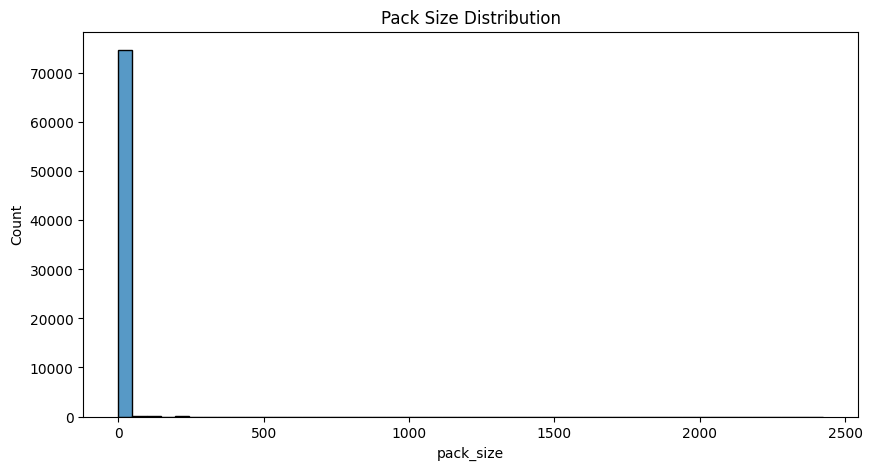

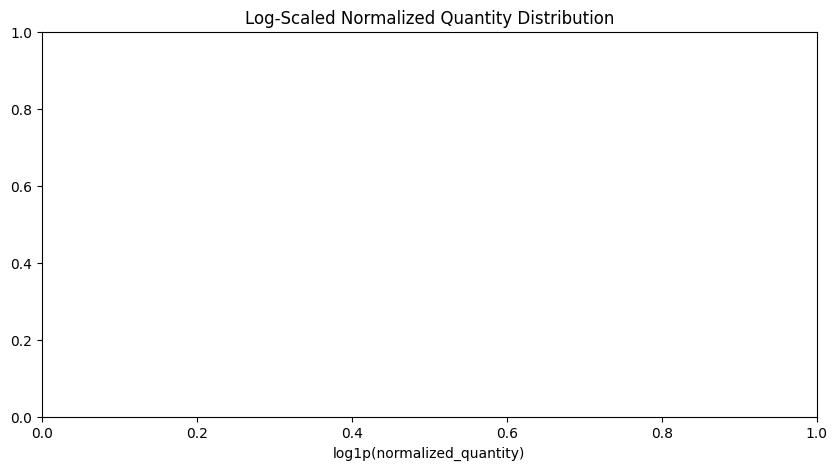

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pack size distribution
plt.figure(figsize=(10,5))
sns.histplot(train['pack_size'], bins=50, kde=False)
plt.title("Pack Size Distribution")
plt.xlabel("pack_size")
plt.show()

# Normalized quantity distribution (log scale to handle skew)
plt.figure(figsize=(10,5))
sns.histplot(train['normalized_quantity'].dropna().apply(np.log1p), bins=50, kde=True, color="orange")
plt.title("Log-Scaled Normalized Quantity Distribution")
plt.xlabel("log1p(normalized_quantity)")
plt.show()


In [52]:
# Cap pack_size at 64
train['pack_size_clipped'] = train['pack_size'].clip(upper=64)
test['pack_size_clipped'] = test['pack_size'].clip(upper=64)

# Bulk flag
train['is_bulk_pack'] = (train['pack_size'] > 50).astype(int)
test['is_bulk_pack'] = (test['pack_size'] > 50).astype(int)

# Cap normalized_quantity at 10,000 (10kg/10L)
train['normalized_quantity_clipped'] = train['normalized_quantity'].clip(upper=10000)
test['normalized_quantity_clipped'] = test['normalized_quantity'].clip(upper=10000)

# Log quantity
train['log_quantity'] = np.log1p(train['normalized_quantity_clipped'])
test['log_quantity'] = np.log1p(test['normalized_quantity_clipped'])

# Missing indicator
train['quantity_missing'] = train['normalized_quantity'].isna().astype(int)
test['quantity_missing'] = test['normalized_quantity'].isna().astype(int)

train[['pack_size','pack_size_clipped','is_bulk_pack','normalized_quantity','normalized_quantity_clipped','log_quantity','quantity_missing']].head(10)


,pack_size,pack_size_clipped,is_bulk_pack,normalized_quantity,normalized_quantity_clipped,log_quantity,quantity_missing
0,6,6,0,NaN,NaN,NaN,1
1,4,4,0,NaN,NaN,NaN,1
2,6,6,0,NaN,NaN,NaN,1
3,1,1,0,NaN,NaN,NaN,1
4,1,1,0,NaN,NaN,NaN,1
5,1,1,0,NaN,NaN,NaN,1
6,6,6,0,NaN,NaN,NaN,1
7,1,1,0,NaN,NaN,NaN,1
8,1,1,0,NaN,NaN,NaN,1
9,4,4,0,NaN,NaN,NaN,1


In [53]:
# Frequency encoding for brand
brand_freq = train['brand'].value_counts().to_dict()
train['brand_freq'] = train['brand'].map(brand_freq)
test['brand_freq'] = test['brand'].map(brand_freq).fillna(0)
train[['brand','brand_freq']].head(10)


,brand,brand_freq
0,La,341
1,Salerno,2
2,Bear,45
3,Judee’S,10
4,Kedem,37
5,Member'S,68
6,Goya,424
7,Vineco,17
8,Natures,70
9,Mrs.,130


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Combine train+test text for consistent vectorization
all_text = pd.concat([train['catalog_content'], test['catalog_content']])

# TF-IDF setup
tfidf = TfidfVectorizer(
    max_features=50000,   # cap vocab
    ngram_range=(1,2),    # word unigrams + bigrams
    analyzer='word',
    min_df=3              # ignore very rare terms
)

# Fit on all text
tfidf_matrix = tfidf.fit_transform(all_text)

print("TF-IDF shape (combined):", tfidf_matrix.shape)

# Dimensionality reduction
svd = TruncatedSVD(n_components=200, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print("Reduced TF-IDF shape:", tfidf_reduced.shape)

# Split back into train/test
X_tfidf_train = tfidf_reduced[:len(train)]
X_tfidf_test = tfidf_reduced[len(train):]

X_tfidf_train[:5]


TF-IDF shape (combined): (150000, 50000)
Reduced TF-IDF shape: (150000, 200)


array([[ 8.84684146e-02, -9.37226385e-02,  1.89781283e-01,
         7.48537283e-02, -3.11063351e-02, -1.75764455e-01,
        -2.18426892e-02, -1.58149330e-02,  4.30527736e-03,
        -1.37391470e-02, -1.13023740e-03, -5.65446421e-02,
        -1.07124140e-01,  2.41559958e-02,  1.77642685e-02,
         1.86255368e-02,  3.74512563e-02, -2.67950697e-03,
         4.89328806e-02,  4.15088176e-02, -4.61330836e-02,
         2.14769038e-02,  6.95244852e-03,  4.96580402e-02,
         7.64747460e-03,  9.57335329e-03,  1.64344552e-02,
         4.07477723e-02, -3.63698036e-02,  3.79755282e-02,
         1.73875073e-02, -3.89246527e-03, -3.71556955e-02,
         1.71308947e-02, -7.59395411e-03,  1.68360344e-02,
        -1.29644500e-02, -2.09125228e-02, -2.14462118e-02,
        -2.74442342e-02, -1.17713940e-02,  1.80179865e-02,
        -2.36604958e-02,  5.35328891e-02,  1.21640297e-02,
         1.14775848e-02, -2.83549808e-02,  3.40765218e-02,
         1.04524603e-02, -1.25915213e-02, -1.47344073e-0

In [55]:
import re
import numpy as np

# -------------------------------
# Robust pack-size via extra regex
# -------------------------------
def extract_pack_regex(text):
    """
    Extract pack size from common patterns in catalog_content.
    Supports: 'Pack of X', 'X-pack', 'X count/ct/pcs', 'Quantity: X'.
    """
    if not isinstance(text, str):
        return np.nan
    patterns = [
        r'[Pp]ack of (\d+)',
        r'(\d+)[ -]?[Pp]ack',
        r'(\d+)\s?(?:count|ct|pcs|pieces)',
        r'[Qq]uantity[: ]?(\d+)',
        r'[Cc]ase of (\d+)',
        r'(\d+)\s?(?:bottles|cans|sachets|tabs|tablets|capsules)'
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return int(m.group(1))
    return np.nan

# regex-derived pack size
train['pack_size_regex'] = train['catalog_content'].apply(extract_pack_regex)
test['pack_size_regex']  = test['catalog_content'].apply(extract_pack_regex)

# prefer regex when available, else our earlier parsed/cleaned value
train['pack_size_final'] = train['pack_size_regex'].fillna(train['pack_size_clipped'])
test['pack_size_final']  = test['pack_size_regex'].fillna(test['pack_size_clipped'])

# clip again to be safe
train['pack_size_final'] = train['pack_size_final'].clip(upper=64)
test['pack_size_final']  = test['pack_size_final'].clip(upper=64)

# -------------------------------
# Cheap-item flag (SMAPE safety)
# -------------------------------
train['cheap_flag'] = (train['price'] < 1).astype(int)
test['cheap_flag']  = 0  # unknown in test; keep column shape

# -------------------------------
# Digits from image URL (hidden IPQ signal sometimes)
# -------------------------------
def extract_digits(url):
    if not isinstance(url, str):
        return np.nan
    digs = re.findall(r'\d+', url)
    return int(digs[-1]) if digs else np.nan

train['url_digits'] = train['image_link'].apply(extract_digits)
test['url_digits']  = test['image_link'].apply(extract_digits)

print("✅ Added edge features: pack_size_final, cheap_flag, url_digits")
display(train[['pack_size_clipped','pack_size_regex','pack_size_final','cheap_flag','url_digits']].head(10))


✅ Added edge features: pack_size_final, cheap_flag, url_digits


,pack_size_clipped,pack_size_regex,pack_size_final,cheap_flag,url_digits
0,6,6.0,6.0,0,8
1,4,4.0,4.0,0,71
2,6,6.0,6.0,0,51
3,1,NaN,1.0,0,0
4,1,NaN,1.0,0,37
5,1,NaN,1.0,0,0
6,6,6.0,6.0,0,0
7,1,NaN,1.0,0,71
8,1,NaN,1.0,0,2
9,4,4.0,4.0,0,41


In [56]:
import numpy as np

# UPDATED structured features (with new ones)
struct_features = [
    'pack_size_final',     # NEW: improved pack size
    'is_bulk_pack',
    'log_quantity',
    'quantity_missing',
    'brand_freq',
    'text_length',
    'word_count',
    'url_digits',          # NEW
    'cheap_flag'           # NEW
]

X_struct_train = train[struct_features].fillna(0).to_numpy()
X_struct_test  = test[struct_features].fillna(0).to_numpy()

# Combine with reduced TF-IDF embeddings
X_train = np.hstack([X_struct_train, X_tfidf_train])
X_test  = np.hstack([X_struct_test, X_tfidf_test])

print("Final train matrix shape:", X_train.shape)
print("Final test matrix shape:", X_test.shape)


Final train matrix shape: (75000, 209)
Final test matrix shape: (75000, 209)


In [57]:
import numpy as np

def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error
    """
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100


In [58]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Target (log-transform for stability)
y = np.log1p(train['price'].values)

# Initialize CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

# LightGBM parameters
lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Cross-validation training
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n===== Fold {fold+1} =====")
    
    dtrain = lgb.Dataset(X_train[tr_idx], label=y[tr_idx])
    dvalid = lgb.Dataset(X_train[val_idx], label=y[val_idx])
    
    model = lgb.train(
        lgb_params,
        dtrain,
        valid_sets=[dtrain, dvalid],
        num_boost_round=2000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(200)
        ]
    )
    
    # Predictions
    oof_preds[val_idx] = model.predict(X_train[val_idx], num_iteration=model.best_iteration)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits

# Evaluate CV
mae_log = mean_absolute_error(y, oof_preds)
mae_orig = mean_absolute_error(np.expm1(y), np.expm1(oof_preds))
smape_score = smape(np.expm1(y), np.expm1(oof_preds))

print("\n===== CV Results =====")
print("CV MAE (log-space):", mae_log)
print("CV MAE (original scale):", mae_orig)
print("CV SMAPE:", smape_score)

# Save submission
submission = pd.DataFrame({
    'sample_id': test['sample_id'],
    'price': np.expm1(test_preds)  # invert log1p
})
submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv ✅")



===== Fold 1 =====
Training until validation scores don't improve for 100 rounds
[200]	training's l1: 0.489713	valid_1's l1: 0.57716
[400]	training's l1: 0.419761	valid_1's l1: 0.565584
[600]	training's l1: 0.367649	valid_1's l1: 0.559971
[800]	training's l1: 0.323966	valid_1's l1: 0.556285
[1000]	training's l1: 0.287435	valid_1's l1: 0.553453
[1200]	training's l1: 0.256177	valid_1's l1: 0.551535
[1400]	training's l1: 0.228467	valid_1's l1: 0.549784
[1600]	training's l1: 0.204468	valid_1's l1: 0.548246
[1800]	training's l1: 0.183055	valid_1's l1: 0.547341
[2000]	training's l1: 0.164451	valid_1's l1: 0.54669
Did not meet early stopping. Best iteration is:
[1999]	training's l1: 0.164538	valid_1's l1: 0.546686

===== Fold 2 =====
Training until validation scores don't improve for 100 rounds
[200]	training's l1: 0.491132	valid_1's l1: 0.566945
[400]	training's l1: 0.422019	valid_1's l1: 0.55486
[600]	training's l1: 0.369942	valid_1's l1: 0.54988
[800]	training's l1: 0.326224	valid_1's l1:

In [59]:
import os, json
os.makedirs("../features", exist_ok=True)

struct_cols = [
    'pack_size','is_bulk',
    'unit_per_item','log_unit_per_item',
    'total_content','log_total_content',
    'has_unit','has_total',
    'brand_te',
    'text_length','word_count'
]

# sanity
missing_train = [c for c in struct_cols if c not in train.columns]
missing_test  = [c for c in struct_cols if c not in test.columns]
assert not missing_train and not missing_test, f"Missing: {missing_train} / {missing_test}"

train_struct = train[['sample_id'] + struct_cols].copy()
test_struct  = test[['sample_id']  + struct_cols].copy()

train_struct.to_csv("../features/train_features.csv", index=False)
test_struct.to_csv("../features/test_features.csv", index=False)

print("Saved:")
print("../features/train_features.csv")
print("../features/test_features.csv")


Saved:
../features/train_features.csv
../features/test_features.csv


In [ ]:
print("brand_te in train?", "brand_te" in train.columns)
print("brand_te in test?", "brand_te" in test.columns)


brand_te in train? False
brand_te in test? False


In [ ]:
print("brand in train?", "brand" in train.columns)
print("brand in test?", "brand" in test.columns)
print(train[['catalog_content']].head(3))


brand in train? True
brand in test? False
                                     catalog_content
0  Item Name: La Victoria Green Taco Sauce Mild, ...
1  Item Name: Salerno Cookies, The Original Butte...
2  Item Name: Bear Creek Hearty Soup Bowl, Creamy...
